In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = '/Users/nisitha/Development/Source/python/heroveird/assignment/28Mar_12Apr/Datasets/'
df_application = pd.read_csv(path + 'applications.csv', dtype={'Rejection_Reason': str})
df_branches = pd.read_csv(path + 'branches.csv')
df_customers = pd.read_csv(path + 'customers.csv')
df_defaults = pd.read_csv(path + 'defaults.csv')
df_loans = pd.read_csv(path + 'loans.csv')
df_transactions = pd.read_csv(path + 'transactions.csv')

## 1. Data Quality and Preparation
### > Validate and clean the datasets.
### > Check for missing values, duplicate entries, and inconsistent data.
### > Standardize date formats and remove irrelevant columns.
### > Handle outliers in numeric columns like Loan_Amount, Interest_Rate, andDefault_Amount.

In [3]:
# Store dataframes in a dictionary for easy iteration
dataframes = {
    "df_application": df_application,
    "df_branches": df_branches,
    "df_customers": df_customers,
    "df_defaults": df_defaults,
    "df_loans": df_loans,
    "df_transactions": df_transactions,
}
dataframes

{'df_application':       Application_ID  Loan_ID Customer_ID Application_Date Approval_Date  \
 0            A000001  L000001     C000001       2022-05-11    2020-10-02   
 1            A000002  L000002     C000002       2022-03-18    2022-11-29   
 2            A000003  L000003     C000003       2022-01-17    2023-07-01   
 3            A000004  L000004     C000004       2019-03-09    2024-08-30   
 4            A000005  L000005     C000005       2024-07-18    2020-03-18   
 ...              ...      ...         ...              ...           ...   
 82595        A082596      NaN     C016646       2021-08-19           NaN   
 82596        A082597      NaN     C010571       2021-01-30           NaN   
 82597        A082598      NaN     C006731       2023-04-17           NaN   
 82598        A082599      NaN     C008140       2021-04-22           NaN   
 82599        A082600      NaN     C060782       2023-05-28           NaN   
 
           Loan_Purpose Source_Channel  Processing_Fee A

In [9]:

for name, df in dataframes.items():
    print(f"--- Validating DataFrame Started for: {name} ---")
    print("Shape:", df.shape)
    print("\nInfo:")
    df.info()
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:")
    print(df.duplicated().sum())
    
    primary_column = ''
    if name == "df_application":
        primary_column = 'Application_ID'
    elif name == "df_branches":
        primary_column = 'Branch_ID'
    elif name == "df_customers":
        primary_column = 'Customer_ID'
    elif name == "df_defaults":
        primary_column = 'Default_ID'
    elif name == "df_loans":
        primary_column = 'Loan_ID'
    elif name == "df_transactions":
        primary_column = 'Transaction_ID'

    print(f'\nUnique {primary_column} values:')
    display(df[primary_column].nunique())
    print('Total rows:', len(df))

    print(f"--- Validation Completed for: {name} ---\n\n")

--- Validating DataFrame Started for: df_application ---
Shape: (82600, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Application_ID    82600 non-null  object
 1   Loan_ID           70000 non-null  object
 2   Customer_ID       82600 non-null  object
 3   Application_Date  82600 non-null  object
 4   Approval_Date     70000 non-null  object
 5   Loan_Purpose      82600 non-null  object
 6   Source_Channel    82600 non-null  object
 7   Processing_Fee    82600 non-null  int64 
 8   Approval_Status   82600 non-null  object
 9   Rejection_Reason  12600 non-null  object
dtypes: int64(1), object(9)
memory usage: 6.3+ MB

Missing values:
Application_ID          0
Loan_ID             12600
Customer_ID             0
Application_Date        0
Approval_Date       12600
Loan_Purpose            0
Source_Channel          0
Process

82600

Total rows: 82600
--- Validation Completed for: df_application ---


--- Validating DataFrame Started for: df_branches ---
Shape: (50, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Branch_ID                   50 non-null     object
 1   Branch_Name                 50 non-null     object
 2   Region                      50 non-null     object
 3   Total_Customers             50 non-null     int64 
 4   Total_Active_Loans          50 non-null     int64 
 5   Delinquent_Loans            50 non-null     int64 
 6   Loan_Disbursement_Amount    50 non-null     int64 
 7   Avg_Processing_Time         50 non-null     int64 
 8   Relationship_Manager_Count  50 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 3.6+ KB

Missing values:
Branch_ID                     0
Branch_Name                   0
Region

50

Total rows: 50
--- Validation Completed for: df_branches ---


--- Validating DataFrame Started for: df_customers ---
Shape: (70000, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer_ID              70000 non-null  object
 1   Full_Name                70000 non-null  object
 2   Contact_Number           70000 non-null  int64 
 3   Email                    70000 non-null  object
 4   Address                  70000 non-null  object
 5   Age                      70000 non-null  int64 
 6   Gender                   70000 non-null  object
 7   Marital_Status           70000 non-null  object
 8   Employment_Status        70000 non-null  object
 9   Annual_Income            70000 non-null  int64 
 10  Credit_Score             70000 non-null  int64 
 11  Region                   70000 non-null  object
 12  

...

Total rows: 9000
--- Validation Completed for: df_defaults ---


--- Validating DataFrame Started for: df_loans ---
Shape: (90000, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               90000 non-null  object 
 1   Customer_ID           90000 non-null  object 
 2   Loan_Amount           90000 non-null  int64  
 3   Interest_Rate         90000 non-null  float64
 4   Loan_Term             90000 non-null  int64  
 5   Disbursal_Date        90000 non-null  object 
 6   Repayment_Start_Date  90000 non-null  object 
 7   Repayment_End_Date    90000 non-null  object 
 8   Loan_Status           90000 non-null  object 
 9   Overdue_Amount        90000 non-null  int64  
 10  EMI_Amount            90000 non-null  int64  
 11  Collateral_Details    59806 non-null  object 
dtypes: float64(1), int64(4), objec

90000

Total rows: 90000
--- Validation Completed for: df_loans ---


--- Validating DataFrame Started for: df_transactions ---
Shape: (495000, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495000 entries, 0 to 494999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Transaction_ID     495000 non-null  object
 1   Loan_ID            495000 non-null  object
 2   Customer_ID        495000 non-null  object
 3   Transaction_Date   495000 non-null  object
 4   Payment_Type       495000 non-null  object
 5   Amount             495000 non-null  int64 
 6   Overdue_Fee        495000 non-null  int64 
 7   Remaining_Balance  495000 non-null  int64 
 8   Mode_of_Payment    495000 non-null  object
dtypes: int64(3), object(6)
memory usage: 34.0+ MB

Missing values:
Transaction_ID       0
Loan_ID              0
Customer_ID          0
Transaction_Date     0
Payment_Type         0
Amount               0
Overdue_F

495000

Total rows: 495000
--- Validation Completed for: df_transactions ---




In [10]:
# Standardize date formats for df_application
df_application['Application_Date'] = pd.to_datetime(df_application['Application_Date'])
df_application['Approval_Date'] = pd.to_datetime(df_application['Approval_Date'])

# Remove 'Rejection_Reason' column due to high missing values
df_application = df_application.drop(columns=['Rejection_Reason'])

print('--- df_application after cleaning ---')
display(df_application.head())
df_application.info()

--- df_application after cleaning ---


,Application_ID,Loan_ID,Customer_ID,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status
0,A000001,L000001,C000001,2022-05-11,2020-10-02,Business,Agent,6427,Approved
1,A000002,L000002,C000002,2022-03-18,2022-11-29,Education,Online,8605,Approved
2,A000003,L000003,C000003,2022-01-17,2023-07-01,Business,Online,1450,Approved
3,A000004,L000004,C000004,2019-03-09,2024-08-30,Home Renovation,Agent,8171,Approved
4,A000005,L000005,C000005,2024-07-18,2020-03-18,Education,Branch,4931,Approved


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Application_ID    82600 non-null  object        
 1   Loan_ID           70000 non-null  object        
 2   Customer_ID       82600 non-null  object        
 3   Application_Date  82600 non-null  datetime64[ns]
 4   Approval_Date     70000 non-null  datetime64[ns]
 5   Loan_Purpose      82600 non-null  object        
 6   Source_Channel    82600 non-null  object        
 7   Processing_Fee    82600 non-null  int64         
 8   Approval_Status   82600 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 5.7+ MB


In [11]:
# Standardize date formats for df_defaults
df_defaults['Default_Date'] = pd.to_datetime(df_defaults['Default_Date'])

display(df_defaults.head())
df_defaults.info()

,Default_ID,Loan_ID,Customer_ID,Default_Date,Default_Amount,Default_Reason,Recovery_Status,Recovery_Amount,Legal_Action
0,D000001,L007312,C007312,2022-07-20,94480,Job Loss,Full,30360,Yes
1,D000002,L028234,C028234,2023-09-23,10912,Job Loss,Partial,0,Yes
2,D000003,L008319,C008319,2024-08-04,73711,Other,NaN,9866,Yes
3,D000004,L046668,C046668,2021-10-16,48955,Other,NaN,0,Yes
4,D000005,L082934,C082934,2024-10-07,56952,Medical Emergency,NaN,0,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Default_ID       9000 non-null   object        
 1   Loan_ID          9000 non-null   object        
 2   Customer_ID      9000 non-null   object        
 3   Default_Date     9000 non-null   datetime64[ns]
 4   Default_Amount   9000 non-null   int64         
 5   Default_Reason   9000 non-null   object        
 6   Recovery_Status  6015 non-null   object        
 7   Recovery_Amount  9000 non-null   int64         
 8   Legal_Action     9000 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 632.9+ KB


In [12]:
# Standardize date formats for df_loans
df_loans['Disbursal_Date'] = pd.to_datetime(df_loans['Disbursal_Date'])
df_loans['Repayment_Start_Date'] = pd.to_datetime(df_loans['Repayment_Start_Date'])
df_loans['Repayment_End_Date'] = pd.to_datetime(df_loans['Repayment_End_Date'])

# Remove 'Collateral_Details' column due to high missing values
df_loans = df_loans.drop(columns=['Collateral_Details'])

print('\n--- df_loans after cleaning ---')
display(df_loans.head())
df_loans.info()


--- df_loans after cleaning ---


,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,EMI_Amount
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Active,0,18668
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Closed,44003,36012
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Overdue,0,26347
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Active,0,16106
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Overdue,0,10127


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Loan_ID               90000 non-null  object        
 1   Customer_ID           90000 non-null  object        
 2   Loan_Amount           90000 non-null  int64         
 3   Interest_Rate         90000 non-null  float64       
 4   Loan_Term             90000 non-null  int64         
 5   Disbursal_Date        90000 non-null  datetime64[ns]
 6   Repayment_Start_Date  90000 non-null  datetime64[ns]
 7   Repayment_End_Date    90000 non-null  datetime64[ns]
 8   Loan_Status           90000 non-null  object        
 9   Overdue_Amount        90000 non-null  int64         
 10  EMI_Amount            90000 non-null  int64         
dtypes: datetime64[ns](3), float64(1), int64(4), object(3)
memory usage: 7.6+ MB


In [13]:
# Standardize date formats for df_transactions
df_transactions['Transaction_Date'] = pd.to_datetime(df_transactions['Transaction_Date'])

print('\n--- df_transactions after cleaning ---')
display(df_transactions.head())
df_transactions.info()


--- df_transactions after cleaning ---


,Transaction_ID,Loan_ID,Customer_ID,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment
0,T00000001,L005588,C050792,2021-04-30,EMI,46099,1313,1513669,NEFT
1,T00000002,L019942,C008919,2021-12-14,Penalty,43648,4852,901455,UPI
2,T00000003,L014848,C016745,2021-01-26,EMI,1810,0,1922629,Cash
3,T00000004,L041104,C039957,2021-02-18,Penalty,8607,708,213581,UPI
4,T00000005,L002488,C056156,2024-12-07,Penalty,34720,0,411621,UPI


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495000 entries, 0 to 494999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Transaction_ID     495000 non-null  object        
 1   Loan_ID            495000 non-null  object        
 2   Customer_ID        495000 non-null  object        
 3   Transaction_Date   495000 non-null  datetime64[ns]
 4   Payment_Type       495000 non-null  object        
 5   Amount             495000 non-null  int64         
 6   Overdue_Fee        495000 non-null  int64         
 7   Remaining_Balance  495000 non-null  int64         
 8   Mode_of_Payment    495000 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 34.0+ MB


In [14]:
# Function to handle outliers using IQR method
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the bounds
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    print(f"Outliers in '{column}' handled. New min: {df[column].min():.2f}, new max: {df[column].max():.2f}")

In [15]:
# Handle outliers in df_loans
print('--- Handling outliers in df_loans ---')
handle_outliers_iqr(df_loans, 'Loan_Amount')
handle_outliers_iqr(df_loans, 'Interest_Rate')

# Handle outliers in df_defaults
print('\n--- Handling outliers in df_defaults ---')
handle_outliers_iqr(df_defaults, 'Default_Amount')

print('\n--- Descriptive statistics after outlier handling ---')
print('df_loans:')
display(df_loans[['Loan_Amount', 'Interest_Rate']].describe())
print('\ndf_defaults:')
display(df_defaults[['Default_Amount']].describe())

--- Handling outliers in df_loans ---
Outliers in 'Loan_Amount' handled. New min: 50026.00, new max: 4999958.00
Outliers in 'Interest_Rate' handled. New min: 7.00, new max: 15.00

--- Handling outliers in df_defaults ---
Outliers in 'Default_Amount' handled. New min: 5010.00, new max: 99997.00

--- Descriptive statistics after outlier handling ---
df_loans:


,Loan_Amount,Interest_Rate
count,9.000000e+04,90000.000000
mean,2.516259e+06,11.005393
std,1.429289e+06,2.307139
min,5.002600e+04,7.000000
25%,1.275705e+06,9.000000
50%,2.510076e+06,11.010000
75%,3.751702e+06,13.010000
max,4.999958e+06,15.000000



df_defaults:


,Default_Amount
count,9000.000000
mean,52978.639667
std,27460.213066
min,5010.000000
25%,29486.500000
50%,53486.500000
75%,77012.000000
max,99997.000000


# 2. Descriptive Analysis
##    Summarize and visualize key metrics:
###       o Distribution of Loan_Amount, EMI_Amount, and Credit_Score.
###       o Regional trends in loan disbursement and defaults.
###       o Monthly trends in loan approvals and disbursements.

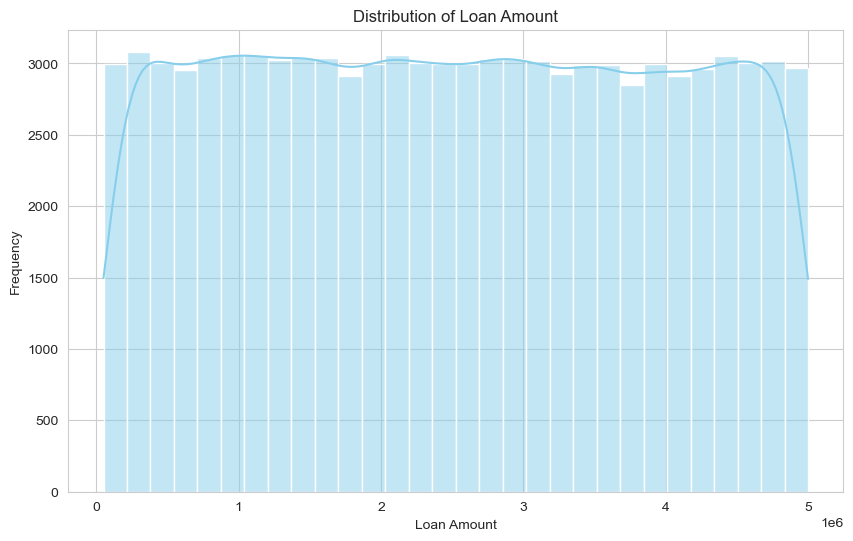

In [17]:
# Set up the aesthetic for the plots
sns.set_style("whitegrid")

# Distribution of Loan_Amount
plt.figure(figsize=(10, 6))
sns.histplot(df_loans['Loan_Amount'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

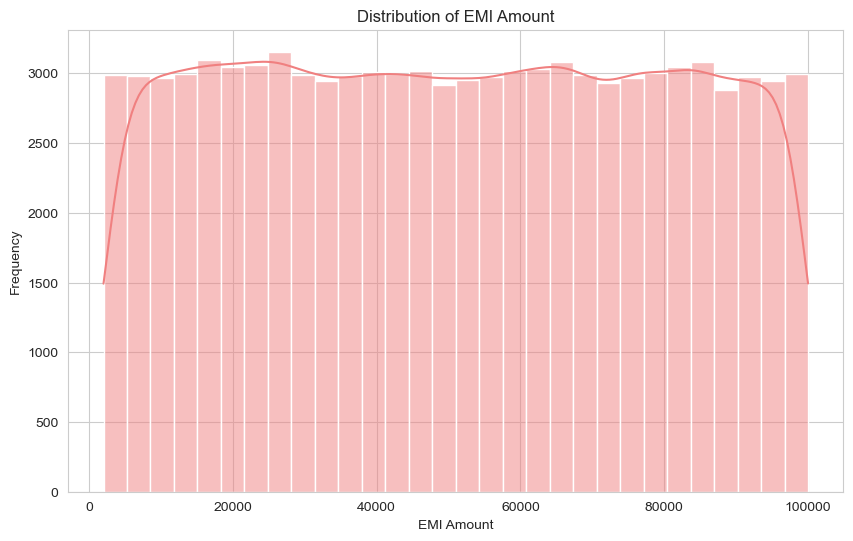

In [18]:
# Distribution of EMI_Amount
plt.figure(figsize=(10, 6))
sns.histplot(df_loans['EMI_Amount'], kde=True, bins=30, color='lightcoral')
plt.title('Distribution of EMI Amount')
plt.xlabel('EMI Amount')
plt.ylabel('Frequency')
plt.show()

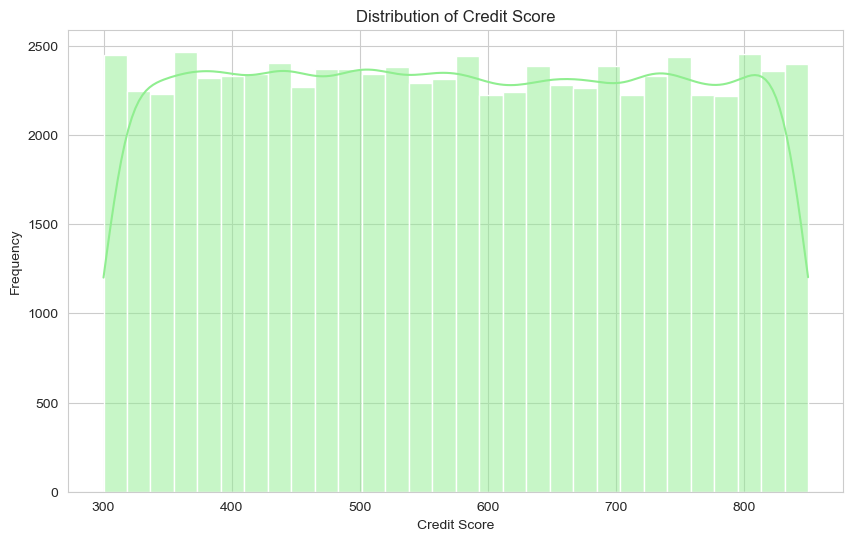

In [19]:
# Distribution of Credit_Score
plt.figure(figsize=(10, 6))
sns.histplot(df_customers['Credit_Score'], kde=True, bins=30, color='lightgreen')
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

In [20]:
# Merge df_loans with df_customers to get region information for loans
loans_regional = pd.merge(df_loans, df_customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

# Calculate total loan amount disbursed per region
regional_loan_disbursement = loans_regional.groupby('Region')['Loan_Amount'].sum().reset_index()
regional_loan_disbursement.rename(columns={'Loan_Amount': 'Total_Loan_Disbursed'}, inplace=True)

print('Regional Loan Disbursement:')
display(regional_loan_disbursement)

Regional Loan Disbursement:


,Region,Total_Loan_Disbursed
0,Central,37243437019
1,East,38437798746
2,North,37963952967
3,Northeast,37477362151
4,South,37740573537
5,West,37600155243


In [21]:
# Merge df_defaults with df_customers to get region information for defaults
defaults_regional = pd.merge(df_defaults, df_customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

# Calculate total defaults per region
regional_defaults = defaults_regional.groupby('Region').size().reset_index(name='Total_Defaults')

print('\nRegional Defaults:')
display(regional_defaults)


Regional Defaults:


,Region,Total_Defaults
0,Central,1158
1,East,1200
2,North,1169
3,Northeast,1155
4,South,1161
5,West,1171


In [22]:
# Combine loan disbursement and default data for regional analysis
regional_analysis = pd.merge(regional_loan_disbursement, regional_defaults, on='Region', how='outer').fillna(0)

# Calculate Default Rate per region (if applicable, avoiding division by zero)
regional_analysis['Default_Rate'] = (regional_analysis['Total_Defaults'] / regional_analysis['Total_Loan_Disbursed']) * 100
regional_analysis.loc[regional_analysis['Total_Loan_Disbursed'] == 0, 'Default_Rate'] = 0

print('\nCombined Regional Analysis:')
display(regional_analysis)

# Sort by Default_Rate for better visualization
regional_analysis_sorted = regional_analysis.sort_values(by='Default_Rate', ascending=False)


Combined Regional Analysis:


,Region,Total_Loan_Disbursed,Total_Defaults,Default_Rate
0,Central,37243437019,1158,0.000003
1,East,38437798746,1200,0.000003
2,North,37963952967,1169,0.000003
3,Northeast,37477362151,1155,0.000003
4,South,37740573537,1161,0.000003
5,West,37600155243,1171,0.000003


/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/1610685552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Total_Loan_Disbursed', data=regional_analysis_sorted, palette='viridis')


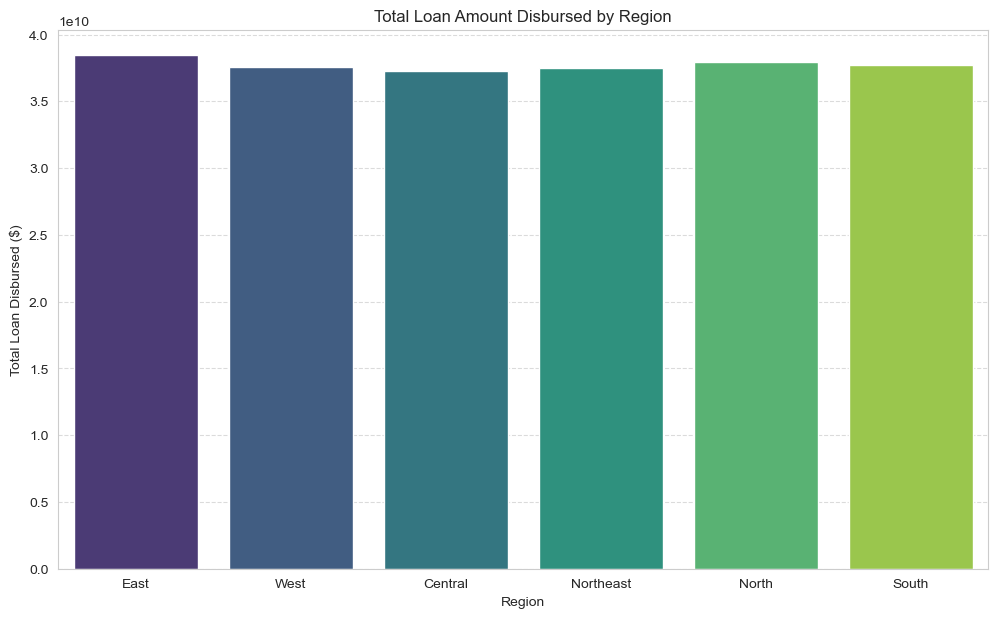

/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/1610685552.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Total_Defaults', data=regional_analysis_sorted, palette='magma')


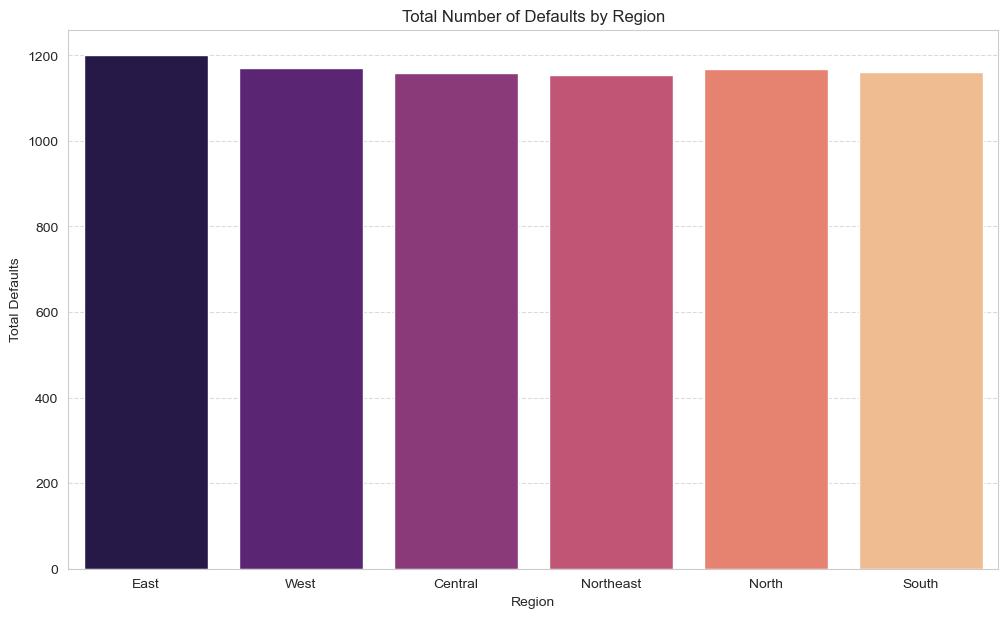

/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/1610685552.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Default_Rate', data=regional_analysis_sorted, palette='cividis')


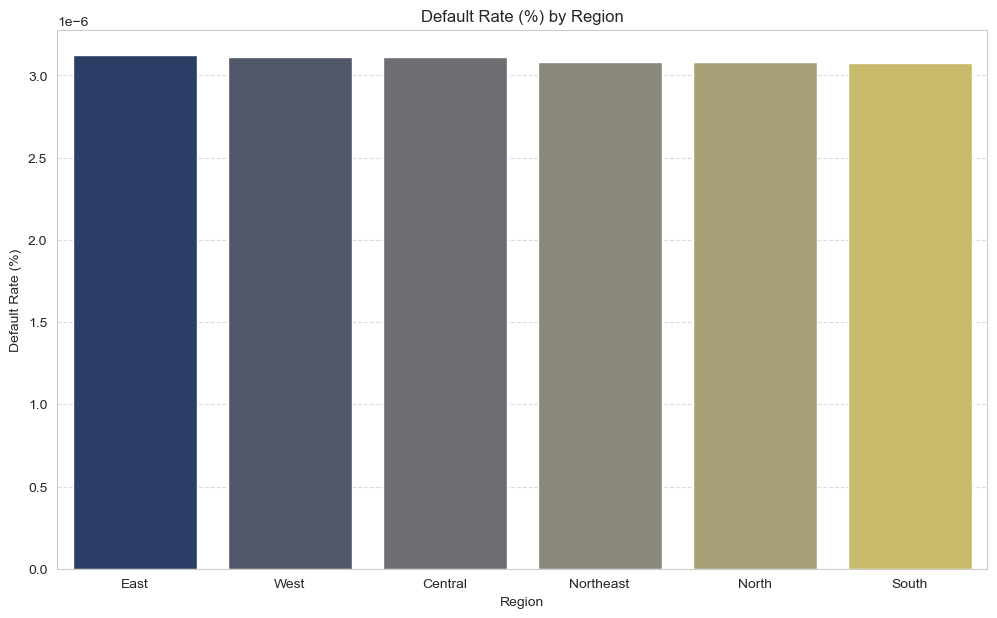

In [23]:
# Visualize Regional Loan Disbursement
plt.figure(figsize=(12, 7))
sns.barplot(x='Region', y='Total_Loan_Disbursed', data=regional_analysis_sorted, palette='viridis')
plt.title('Total Loan Amount Disbursed by Region')
plt.xlabel('Region')
plt.ylabel('Total Loan Disbursed ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize Regional Defaults
plt.figure(figsize=(12, 7))
sns.barplot(x='Region', y='Total_Defaults', data=regional_analysis_sorted, palette='magma')
plt.title('Total Number of Defaults by Region')
plt.xlabel('Region')
plt.ylabel('Total Defaults')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize Regional Default Rate
plt.figure(figsize=(12, 7))
sns.barplot(x='Region', y='Default_Rate', data=regional_analysis_sorted, palette='cividis')
plt.title('Default Rate (%) by Region')
plt.xlabel('Region')
plt.ylabel('Default Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [30]:
# Monthly Loan Approvals from df_application (for Approved Status)
approved_applications = df_application[df_application['Approval_Status'] == 'Approved'].copy()
approved_applications['Approval_Month_Year'] = approved_applications['Approval_Date'].dt.to_period('M')
monthly_approvals = approved_applications.groupby('Approval_Month_Year').size().reset_index(name='Total_Approvals')
monthly_approvals['Approval_Month_Year'] = monthly_approvals['Approval_Month_Year'].dt.to_timestamp()

# Monthly Loan Disbursements from df_loans
df_loans['Disbursal_Month_Year'] = df_loans['Disbursal_Date'].dt.to_period('M')
monthly_disbursements = df_loans.groupby('Disbursal_Month_Year')['Loan_Amount'].sum().reset_index(name='Total_Loan_Disbursed')
monthly_disbursements['Disbursal_Month_Year'] = monthly_disbursements['Disbursal_Month_Year'].dt.to_timestamp()

print('Monthly Loan Approvals:')
display(monthly_approvals.head())

print('\nMonthly Loan Disbursements:')
display(monthly_disbursements.head())

Monthly Loan Approvals:


,Approval_Month_Year,Total_Approvals
0,2020-01-01,1152
1,2020-02-01,1176
2,2020-03-01,1172
3,2020-04-01,1121
4,2020-05-01,1170



Monthly Loan Disbursements:


,Disbursal_Month_Year,Total_Loan_Disbursed
0,2019-12-01,491271344
1,2020-01-01,3908302834
2,2020-02-01,3621088694
3,2020-03-01,4031554268
4,2020-04-01,3817013578


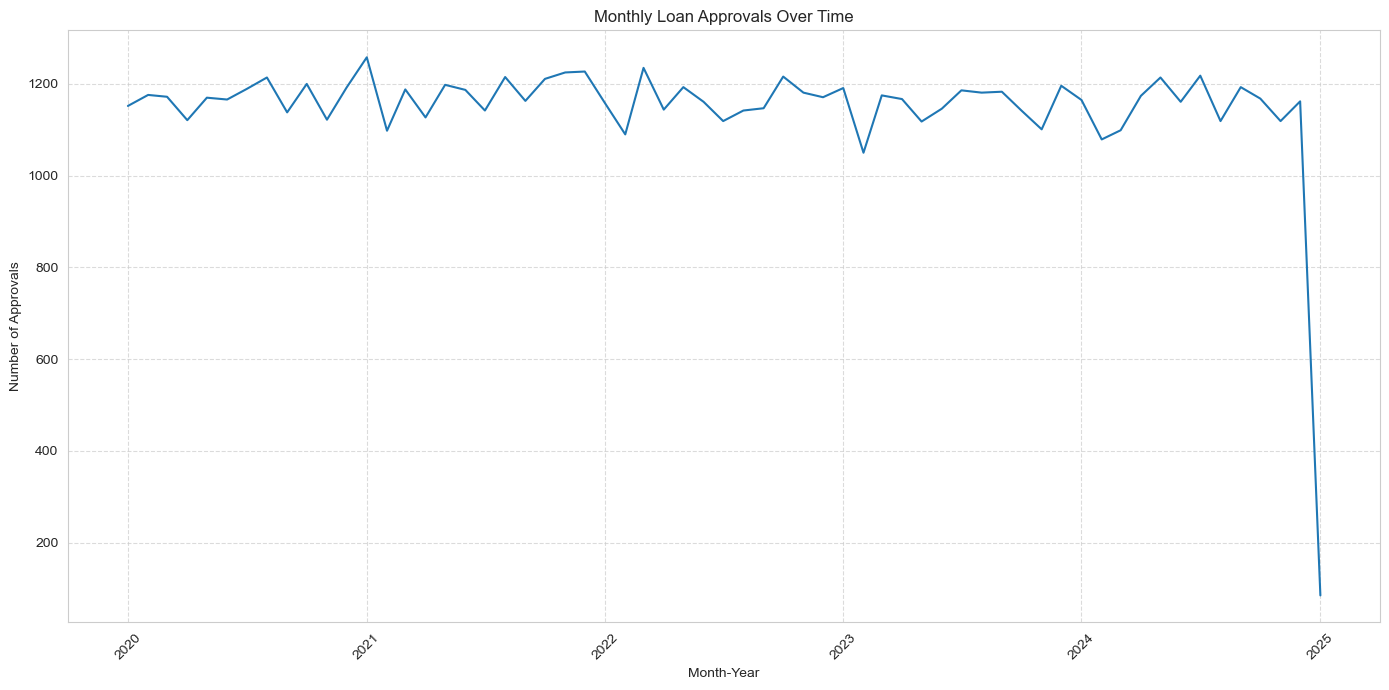

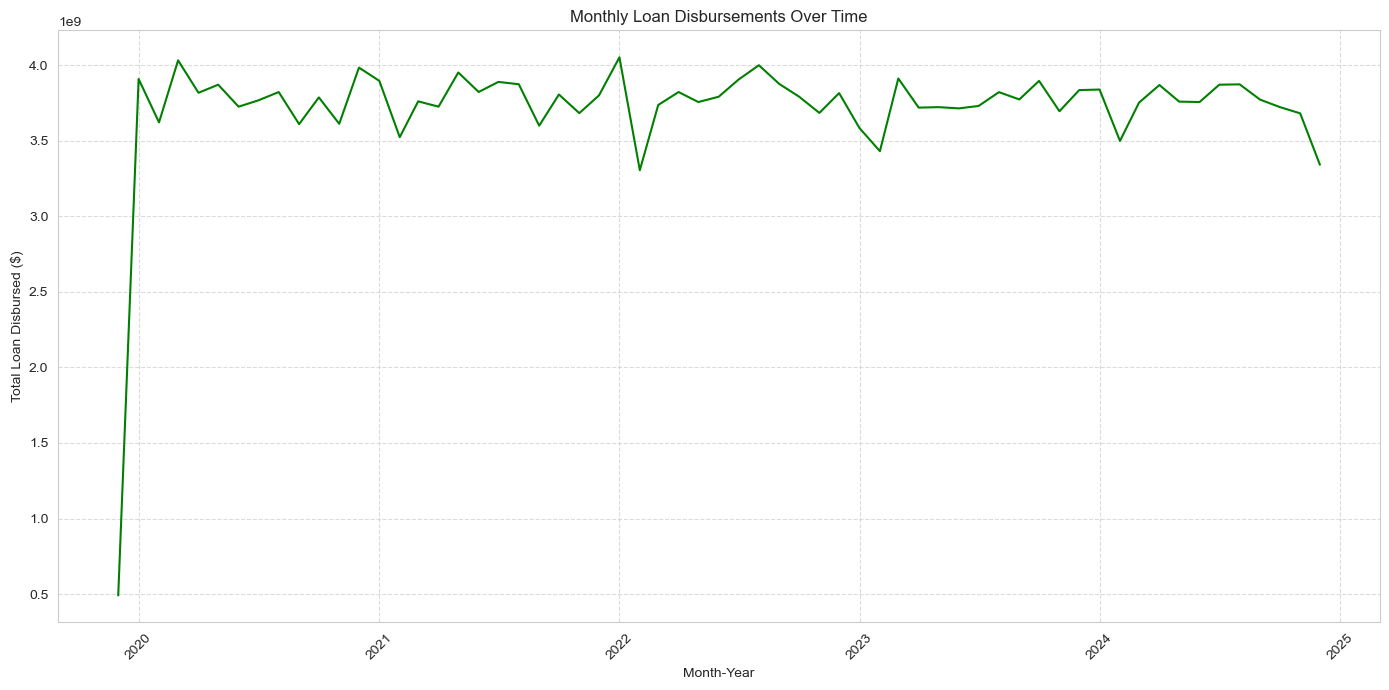

In [31]:
# Visualize Monthly Loan Approvals
plt.figure(figsize=(14, 7))
sns.lineplot(x='Approval_Month_Year', y='Total_Approvals', data=monthly_approvals)
plt.title('Monthly Loan Approvals Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Approvals')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize Monthly Loan Disbursements
plt.figure(figsize=(14, 7))
sns.lineplot(x='Disbursal_Month_Year', y='Total_Loan_Disbursed', data=monthly_disbursements, color='green')
plt.title('Monthly Loan Disbursements Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Loan Disbursed ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Default Risk Analysis
##      Correlation Between Loan Attributes and Defaults:
###           Calculate correlations between Loan_Amount, Interest_Rate, Credit_Score, and Default_Flag (a binary indicator for default).

##      Pairwise Correlation Analysis:
###           Create a heatmap to visualize the correlations between key variables, such as EMI_Amount, Overdue_Amount, and Default_Amount.

##      Correlation Between Branch Metrics and Defaults:
###           Analyze the relationship between branch performance metrics (e.g.,Delinquent_Loans, Loan_Disbursement_Amount) and default rates.

In [32]:
df_loans['Default_Flag'] = df_loans['Loan_ID'].isin(df_defaults['Loan_ID']).astype(int)

# Merge df_loans with df_customers to get 'Credit_Score'
correlation_df = pd.merge(df_loans, df_customers[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')

# Select relevant columns for correlation
correlation_columns = ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']
correlation_matrix = correlation_df[correlation_columns].corr()

print('Correlation Matrix:')
display(correlation_matrix)

Correlation Matrix:


,Loan_Amount,Interest_Rate,Credit_Score,Default_Flag
Loan_Amount,1.000000,-0.003201,0.000139,-0.003313
Interest_Rate,-0.003201,1.000000,0.002457,-0.003750
Credit_Score,0.000139,0.002457,1.000000,-0.001580
Default_Flag,-0.003313,-0.003750,-0.001580,1.000000


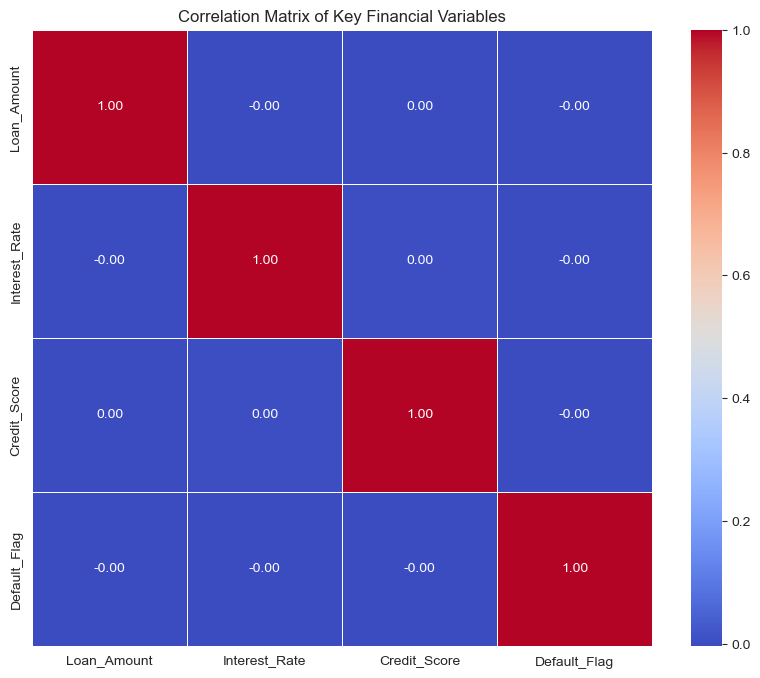

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Key Financial Variables')
plt.show()

In [34]:
# Merge df_defaults with correlation_df to include 'Default_Amount'
# Use a left merge to keep all loans and add default amount where applicable
correlation_financial_df = pd.merge(correlation_df, df_defaults[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')

# Select relevant columns for correlation
financial_correlation_columns = ['EMI_Amount', 'Overdue_Amount', 'Default_Amount']
financial_correlation_matrix = correlation_financial_df[financial_correlation_columns].corr()

print('Correlation Matrix for Financial Specifics:')
display(financial_correlation_matrix)

Correlation Matrix for Financial Specifics:


,EMI_Amount,Overdue_Amount,Default_Amount
EMI_Amount,1.000000,0.000386,0.007650
Overdue_Amount,0.000386,1.000000,-0.010207
Default_Amount,0.007650,-0.010207,1.000000


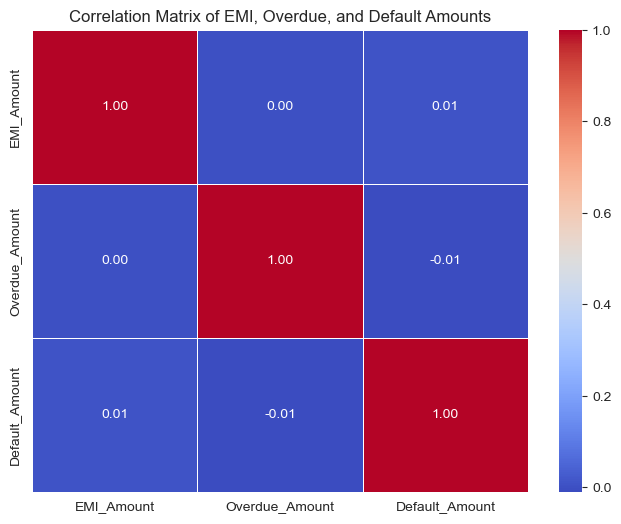

In [35]:
# Visualize the correlation matrix for financial specifics
plt.figure(figsize=(8, 6))
sns.heatmap(financial_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of EMI, Overdue, and Default Amounts')
plt.show()